# L8 · Convolution from pixels to gradients

**One running example.** We use the same $5\times5$ image and $3\times3$ horizontal-edge kernel as the slides. You will **predict**, **calculate**, **run**, **inspect**, and **explain** each result.

By the end you should be able to:

1. compute a feature-map entry by hand;
2. implement padding and stride without a deep-learning library;
3. calculate output shapes, parameter counts, MACs, and receptive fields;
4. explain equivariance and pooling with explicit arrays;
5. verify why a shared kernel gradient sums over spatial positions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(8)

X = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
], dtype=float)

K = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1],
], dtype=float)

print('X shape:', X.shape, 'K shape:', K.shape)
print('X =\n', X)
print('K =\n', K)

X shape: (5, 5) K shape: (3, 3)
X =
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
K =
 [[ 1.  1.  1.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]


## 1 · One patch, one output

The first output uses `X[0:3, 0:3]`. Before running the next cell:

- write the nine products $K[u,v]X[u,v]$;
- predict the sign of $Y[0,0]$ from the visual transition;
- calculate the exact sum.

The slide claim is $Y[0,0]=-3$: dark above, bright below.

In [2]:
patch = X[:3, :3]
products = patch * K
y00 = products.sum()

print('patch =\n', patch)
print('elementwise products =\n', products)
print('row sums =', products.sum(axis=1))
print('Y[0,0] =', y00)
assert y00 == -3

patch =
 [[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
elementwise products =
 [[ 0.  0.  0.]
 [ 0.  0.  0.]
 [-1. -1. -1.]]
row sums = [ 0.  0. -3.]
Y[0,0] = -3.0


## 2 · Implement the sliding operation

For one input channel and one kernel, PyTorch's so-called convolution is cross-correlation:

$$Y[i,j]=\sum_{u,v}K[u,v]X[i\,s+u-p,\;j\,s+v-p].$$

Read the loops below before running them. Identify where **padding**, **stride**, and **weight sharing** appear.

In [3]:
def out_size(length, kernel, padding=0, stride=1):
    numerator = length + 2 * padding - kernel
    if numerator < 0:
        raise ValueError('kernel does not fit the padded input')
    return numerator // stride + 1

def conv2d_single(X, K, padding=0, stride=1):
    H, W = X.shape
    kh, kw = K.shape
    Hout = out_size(H, kh, padding, stride)
    Wout = out_size(W, kw, padding, stride)
    Xpad = np.pad(X, ((padding, padding), (padding, padding)))
    Y = np.empty((Hout, Wout), dtype=float)

    for i in range(Hout):
        for j in range(Wout):
            r, c = i * stride, j * stride
            patch = Xpad[r:r+kh, c:c+kw]
            Y[i, j] = np.sum(patch * K)  # the same K at every (i, j)
    return Y


### Predict the full feature map

Without running code, answer:

1. What output shape follows from $H=W=5$, $k=3$, $p=0$, $s=1$?
2. Will each row of the output be constant across columns? Why?
3. Which output row should be positive?

Now reveal the result.

Y =
 [[-3. -3. -3.]
 [-3. -3. -3.]
 [ 3.  3.  3.]]


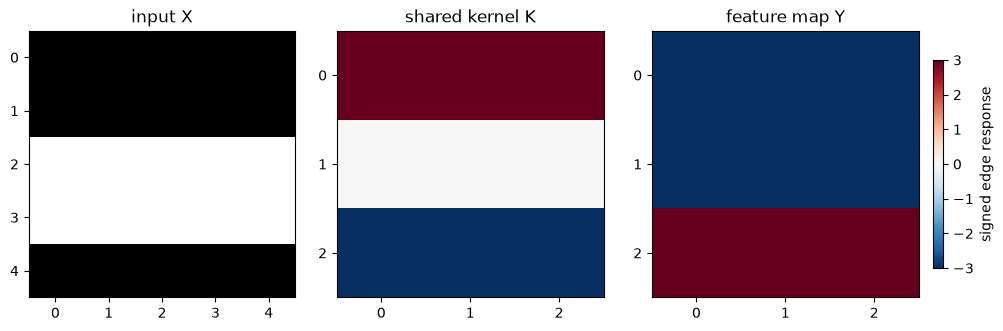

In [4]:
Y = conv2d_single(X, K)
expected = np.array([[-3, -3, -3], [-3, -3, -3], [3, 3, 3]], dtype=float)
np.testing.assert_array_equal(Y, expected)
print('Y =\n', Y)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
im0 = ax[0].imshow(X, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('input X')
im1 = ax[1].imshow(K, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_title('shared kernel K')
im2 = ax[2].imshow(Y, cmap='RdBu_r', vmin=-3, vmax=3)
ax[2].set_title('feature map Y')
for a in ax:
    a.set_xticks(range(a.images[0].get_array().shape[1]))
    a.set_yticks(range(a.images[0].get_array().shape[0]))
    a.grid(False)
fig.colorbar(im2, ax=ax[2], shrink=0.78, label='signed edge response')
plt.show()

### Inspect the sharing explicitly

The next cell prints three patches from the slide sequence. Explain why the kernel values never appear inside the loop as position-specific parameters.

In [5]:
for i, j in [(0, 0), (0, 1), (2, 0)]:
    patch = X[i:i+3, j:j+3]
    print(f'output ({i},{j})')
    print(patch)
    print('dot with the SAME K ->', np.sum(patch * K), '\n')

output (0,0)
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
dot with the SAME K -> -3.0 

output (0,1)
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
dot with the SAME K -> -3.0 

output (2,0)
[[1. 1. 1.]
 [1. 1. 1.]
 [0. 0. 0.]]
dot with the SAME K -> 3.0 



## 3 · Output geometry: count legal starts

$$H_{out}=\left\lfloor\frac{H+2p-k}{s}\right\rfloor+1.$$

Predict all four outputs below before running the tests. For the final case, list the legal start positions explicitly.

In [6]:
cases = [
    # H, k, p, s, expected
    (5, 3, 0, 1, 3),
    (5, 3, 1, 1, 5),
    (7, 3, 1, 2, 4),
    (8, 3, 0, 2, 3),
]
for H, k, p, s, expected in cases:
    got = out_size(H, k, p, s)
    starts = list(range(0, H + 2*p - k + 1, s))
    print(f'H={H}, k={k}, p={p}, s={s}: starts={starts}, Hout={got}')
    assert got == expected == len(starts)

H=5, k=3, p=0, s=1: starts=[0, 1, 2], Hout=3
H=5, k=3, p=1, s=1: starts=[0, 1, 2, 3, 4], Hout=5
H=7, k=3, p=1, s=2: starts=[0, 2, 4, 6], Hout=4
H=8, k=3, p=0, s=2: starts=[0, 2, 4], Hout=3


### See padding and stride change different things

Padding changes which border patches are legal. Stride selects a subset of legal starts. Predict each output shape and then inspect the arrays.

In [7]:
for padding, stride in [(0, 1), (1, 1), (1, 2)]:
    out = conv2d_single(X, K, padding=padding, stride=stride)
    print(f'p={padding}, s={stride}, shape={out.shape}')
    print(out, '\n')

p=0, s=1, shape=(3, 3)
[[-3. -3. -3.]
 [-3. -3. -3.]
 [ 3.  3.  3.]] 

p=1, s=1, shape=(5, 5)
[[ 0.  0.  0.  0.  0.]
 [-2. -3. -3. -3. -2.]
 [-2. -3. -3. -3. -2.]
 [ 2.  3.  3.  3.  2.]
 [ 2.  3.  3.  3.  2.]] 

p=1, s=2, shape=(3, 3)
[[ 0.  0.  0.]
 [-2. -3. -2.]
 [ 2.  3.  2.]] 



## 4 · Channels and parameter counts

A $1\times1$ RGB kernel still spans all three channels. The slide example uses $x=(0.8,0.2,0.5)$ and $w=(0.5,-1,0.4)$. Predict the output before running.

In [8]:
rgb = np.array([0.8, 0.2, 0.5])
weights = np.array([0.5, -1.0, 0.4])
contributions = rgb * weights
print('channel contributions:', contributions)
print('sum:', contributions.sum())
assert np.isclose(contributions.sum(), 0.4)

channel contributions: [ 0.4 -0.2  0.2]
sum: 0.4


In [9]:
def conv_params(kh, kw, c_in, c_out, bias=True):
    return kh * kw * c_in * c_out + (c_out if bias else 0)

def conv_macs(h_out, w_out, kh, kw, c_in, c_out):
    return h_out * w_out * c_out * kh * kw * c_in

# The exact tiny CNN from the slides
p1 = conv_params(3, 3, 3, 16)
p2 = conv_params(3, 3, 16, 32)
p_head = 32 * 10 + 10
m1 = conv_macs(32, 32, 3, 3, 3, 16)
m2 = conv_macs(16, 16, 3, 3, 16, 32)
m_head = 32 * 10

print(f'parameters: conv1={p1:,}, conv2={p2:,}, head={p_head:,}, total={p1+p2+p_head:,}')
print(f'MACs:       conv1={m1:,}, conv2={m2:,}, head={m_head:,}, total={m1+m2+m_head:,}')
assert (p1 + p2 + p_head) == 5_418
assert (m1 + m2 + m_head) == 1_622_336

parameters: conv1=448, conv2=4,640, head=330, total=5,418
MACs:       conv1=442,368, conv2=1,179,648, head=320, total=1,622,336


**Explain in one sentence:** Why does doubling image height and width leave `p1` unchanged but make `m1` approximately four times larger?

## 5 · Equivariance and pooling

A shared convolution should move its response when the input moves. Exact comparisons require care at boundaries. We compare the valid interior below.

In [10]:
signal = np.array([0., 1., 1., 0., 0., 0.])
kernel_1d = np.array([-1., 0., 1.])

def corr1d(x, k):
    return np.array([np.dot(x[i:i+len(k)], k) for i in range(len(x)-len(k)+1)])

shifted = np.r_[0., signal[:-1]]
f = corr1d(signal, kernel_1d)
f_shifted = corr1d(shifted, kernel_1d)
print('x:              ', signal)
print('shift(x):       ', shifted)
print('f(x):           ', f)
print('f(shift(x)):    ', f_shifted)
print('shift(f(x)):    ', np.r_[0., f[:-1]])
np.testing.assert_allclose(f_shifted[1:], f[:-1])

x:               [0. 1. 1. 0. 0. 0.]
shift(x):        [0. 0. 1. 1. 0. 0.]
f(x):            [ 1. -1. -1.  0.]
f(shift(x)):     [ 1.  1. -1. -1.]
shift(f(x)):     [ 0.  1. -1. -1.]


In [11]:
def pool2d(X, window=2, stride=2, mode='max'):
    Hout = out_size(X.shape[0], window, 0, stride)
    Wout = out_size(X.shape[1], window, 0, stride)
    Y = np.empty((Hout, Wout))
    reduce = np.max if mode == 'max' else np.mean
    for i in range(Hout):
        for j in range(Wout):
            patch = X[i*stride:i*stride+window, j*stride:j*stride+window]
            Y[i, j] = reduce(patch)
    return Y

F = np.array([[1,3,2,4], [5,6,1,2], [7,2,3,0], [1,0,4,8]], dtype=float)
print('max pool =\n', pool2d(F, mode='max'))
print('avg pool =\n', pool2d(F, mode='avg'))
print('global average =', F.mean())

max pool =
 [[6. 4.]
 [7. 8.]]
avg pool =
 [[3.75 2.25]
 [2.5  3.75]]
global average = 3.0625


**Explain:** Move the value `6` to a different location inside the same top-left $2\times2$ window. Which pooled outputs remain unchanged? What changes if it crosses into the top-right window?

## 6 · Receptive field and jump

Track $(r,j)$, where $r$ is receptive-field width and $j$ is spacing between adjacent feature-map units in original input pixels:

$$j_l=j_{l-1}s_l,\qquad r_l=r_{l-1}+(k_l-1)j_{l-1}.$$

Predict the rows for `conv3-s1 → pool2-s2 → conv3-s1` before running.

In [12]:
def receptive_field(layers):
    r, j = 1, 1
    rows = [('input', 1, 1, r, j)]
    for name, k, s in layers:
        r = r + (k - 1) * j
        j = j * s
        rows.append((name, k, s, r, j))
    return rows

layers = [('conv1', 3, 1), ('pool', 2, 2), ('conv2', 3, 1)]
print('layer     k  s  r  j')
for name, k, s, r, j in receptive_field(layers):
    print(f'{name:8s} {k:2d} {s:2d} {r:2d} {j:2d}')
assert receptive_field(layers)[-1][-2:] == (8, 2)

layer     k  s  r  j
input     1  1  1  1
conv1     3  1  3  1
pool      2  2  4  2
conv2     3  1  8  2


## 7 · Backprop through shared weights

Use the exact slide example: $x=(2,1,3)$, $k=(0.5,-1)$, $b=0$, and arriving gradient $g=(1,2)$.

Before running, calculate:

- $y_0,y_1$;
- $\partial L/\partial k_0$ and $\partial L/\partial k_1$;
- $\partial L/\partial x_0,\partial L/\partial x_1,\partial L/\partial x_2$;
- $\partial L/\partial b$.

In [13]:
x = np.array([2., 1., 3.])
k = np.array([0.5, -1.])
g = np.array([1., 2.])
b = 0.

y = corr1d(x, k) + b
grad_k = np.array([g[0]*x[0] + g[1]*x[1],
                   g[0]*x[1] + g[1]*x[2]])
grad_x = np.array([g[0]*k[0],
                   g[0]*k[1] + g[1]*k[0],
                   g[1]*k[1]])
grad_b = g.sum()

print('y      =', y)
print('grad_k =', grad_k)
print('grad_x =', grad_x)
print('grad_b =', grad_b)
np.testing.assert_allclose(y, [0., -2.5])
np.testing.assert_allclose(grad_k, [4., 7.])
np.testing.assert_allclose(grad_x, [0.5, 0., -2.])
assert grad_b == 3

y      = [ 0.  -2.5]
grad_k = [4. 7.]
grad_x = [ 0.5  0.  -2. ]
grad_b = 3.0


In [14]:
import torch
import torch.nn.functional as F

xt = torch.tensor(x[None, None, :], dtype=torch.float64, requires_grad=True)
kt = torch.tensor(k[None, None, :], dtype=torch.float64, requires_grad=True)
bt = torch.tensor([b], dtype=torch.float64, requires_grad=True)
gt = torch.tensor(g, dtype=torch.float64)[None, None, :]
yt = F.conv1d(xt, kt, bt)
yt.backward(gt)

print('PyTorch y      =', yt.detach().numpy().ravel())
print('PyTorch grad_k =', kt.grad.numpy().ravel())
print('PyTorch grad_x =', xt.grad.numpy().ravel())
print('PyTorch grad_b =', bt.grad.numpy())
np.testing.assert_allclose(kt.grad.numpy().ravel(), grad_k)
np.testing.assert_allclose(xt.grad.numpy().ravel(), grad_x)
np.testing.assert_allclose(bt.grad.numpy(), [grad_b])

PyTorch y      = [ 0.  -2.5]
PyTorch grad_k = [4. 7.]
PyTorch grad_x = [ 0.5  0.  -2. ]
PyTorch grad_b = [3.]


### Independent finite-difference check

Define a scalar $L=g^Ty$. A central difference perturbs one shared kernel value and automatically changes **both** output positions.

In [15]:
def scalar_loss(k_value):
    return np.dot(g, corr1d(x, k_value) + b)

eps = 1e-6
grad_fd = np.empty_like(k)
for q in range(len(k)):
    direction = np.zeros_like(k)
    direction[q] = eps
    grad_fd[q] = (scalar_loss(k + direction) - scalar_loss(k - direction)) / (2*eps)
print('finite-difference grad_k =', grad_fd)
np.testing.assert_allclose(grad_fd, grad_k, rtol=1e-8, atol=1e-8)

finite-difference grad_k = [4. 7.]


## 8 · Build the exact tiny CNN from the slides

The slides write one image in mathematical $H \times W \times C$ order, here $32 \times 32 \times 3$. PyTorch `Conv2d` expects a batch in $N \times C \times H \times W$ order, so the same input has shape `(1, 3, 32, 32)` below.

Predict each activation shape and the total parameter count before running. No data download or training is required.

In [16]:
from torch import nn

torch.manual_seed(8)
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(32, 10),
)

h = torch.randn(1, 3, 32, 32)
print('input'.ljust(22), tuple(h.shape))
for layer in model:
    h = layer(h)
    print(layer.__class__.__name__.ljust(22), tuple(h.shape))

total = sum(p.numel() for p in model.parameters())
print('total parameters:', total)
assert tuple(h.shape) == (1, 10)
assert total == 5_418

input                  (1, 3, 32, 32)
Conv2d                 (1, 16, 32, 32)
ReLU                   (1, 16, 32, 32)
MaxPool2d              (1, 16, 16, 16)
Conv2d                 (1, 32, 16, 16)
ReLU                   (1, 32, 16, 16)
AdaptiveAvgPool2d      (1, 32, 1, 1)
Flatten                (1, 32)
Linear                 (1, 10)
total parameters: 5418


## Explain before you leave

Write a short answer to each prompt without using the words *because convolution is good for images*:

1. Why does a convolution have few parameters but potentially many MACs?
2. Why is a feature map equivariant rather than invariant to translation?
3. How can stride make receptive fields grow faster?
4. Why does `grad_k` add contributions from multiple output positions?
5. Which information does global average pooling deliberately discard?

**Core mental model:** a kernel is one learned local question, asked everywhere; depth composes the spatial answers into task evidence.